# Topology PoC — Hypothesis Analysis

**Гипотеза:** структурные метрики графа топологии коррелируют с accuracy MAS.

Запусти `python scripts/run_poc.py` перед открытием ноутбука.

## Agent module test — проверка API ключа и пайплайна

In [ ]:
import sys, os
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from mas.agent import Agent, AgentConfig
from mas.prompts import parse_answer

TASK = "Janet's ducks lay 16 eggs per day. She eats 3 for breakfast and bakes 4 into muffins. She sells the rest at $2 per egg. How much does she make per day?"
GT   = 18   # (16 - 3 - 4) * 2 = 18

# ── 1. Stub (без API) ───────────────────────────────────────────────────────
stub_agent = Agent(AgentConfig("A0", "solver", stub=True))
stub_out   = stub_agent.run(TASK, [])
print("=== STUB ===")
print(stub_out)
print()

# ── 2. Real API ────────────────────────────────────────────────────────────
print("=== REAL API ===")
print(f"OPENAI_API_KEY set: {bool(os.environ.get('OPENAI_API_KEY'))}")

real_agent = Agent(AgentConfig("A0", "solver", model="gpt-3.5-turbo", stub=False))
real_out   = real_agent.run(TASK, [])
pred       = parse_answer(real_out)

print(real_out)
print()
print(f"Parsed:  {pred}")
print(f"GT:      {GT}")
print(f"Correct: {pred == GT}")

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

## 1. Загрузка результатов

In [2]:
results_path = Path("../results/results.json")

# --- mock данные для запуска без run_poc.py ---
MOCK = [
    {"topology": "chain",  "accuracy": 0.55,
     "metrics": {"diameter": 2.5, "avg_degree": 1.0, "structural_entropy": 1.50, "spectral_gap": 0.29, "task_centrality": 0.50}},
    {"topology": "star",   "accuracy": 0.60,
     "metrics": {"diameter": 2.0, "avg_degree": 1.0, "structural_entropy": 1.58, "spectral_gap": 0.75, "task_centrality": 1.00}},
    {"topology": "full",   "accuracy": 0.70,
     "metrics": {"diameter": 1.0, "avg_degree": 3.0, "structural_entropy": 2.00, "spectral_gap": 1.00, "task_centrality": 0.22}},
    {"topology": "random", "accuracy": 0.50,
     "metrics": {"diameter": 1.7, "avg_degree": 1.3, "structural_entropy": 1.42, "spectral_gap": 0.55, "task_centrality": 0.35}},
]

if results_path.exists():
    data = json.loads(results_path.read_text())
    print(f"Загружено из {results_path}")
else:
    data = MOCK
    print("⚠️  results.json не найден — используются mock-данные")

df = pd.DataFrame([
    {"topology": r["topology"], "accuracy": r["accuracy"], **r["metrics"]}
    for r in data
])
df

Загружено из ../results/results.json


,topology,accuracy,diameter,avg_degree,structural_entropy,spectral_gap,task_centrality
0,chain,0.2,1.666667,0.75,1.918296,0.500000,0.0
1,star,0.2,1.400000,1.20,2.292481,1.000000,0.0
2,full,0.2,1.000000,1.50,2.000000,1.333333,0.0
3,random,0.2,1.166667,1.25,1.970951,1.000000,0.0


## 2. Scatter plots: метрика vs accuracy

Каждый граф — одна точка. Если гипотеза верна, хотя бы один subplot покажет монотонный тренд.

/var/folders/1f/1t7knmh95bg_g1s30p6r8mp40000gn/T/ipykernel_95317/676898673.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/var/folders/1f/1t7knmh95bg_g1s30p6r8mp40000gn/T/ipykernel_95317/676898673.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/var/folders/1f/1t7knmh95bg_g1s30p6r8mp40000gn/T/ipykernel_95317/676898673.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/var/folders/1f/1t7knmh95bg_g1s30p6r8mp40000gn/T/ipykernel_95317/676898673.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)


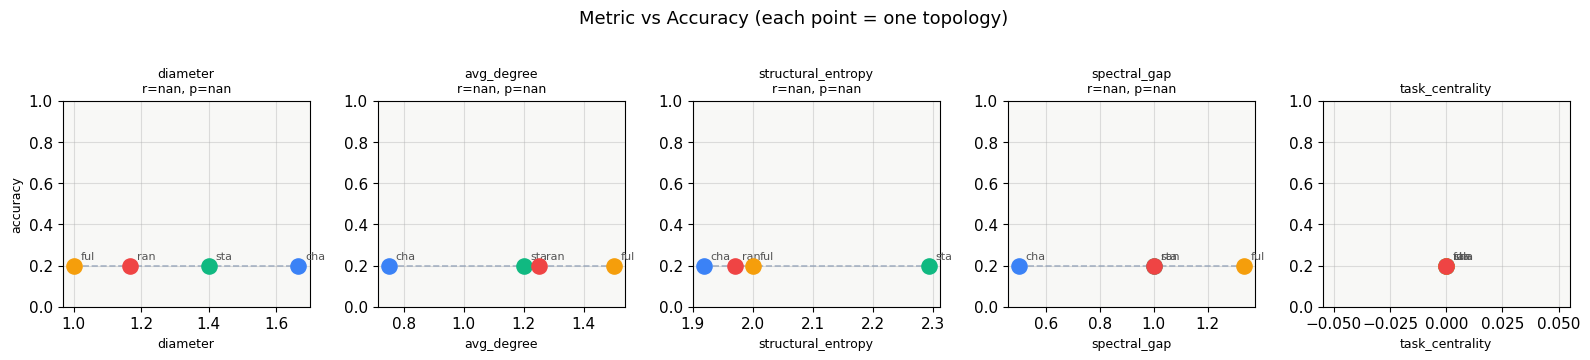

Сохранено → results/scatter_plots.png


In [3]:
METRIC_COLS = ["diameter", "avg_degree", "structural_entropy", "spectral_gap", "task_centrality"]
COLORS = {"chain": "#3B82F6", "star": "#10B981", "full": "#F59E0B", "random": "#EF4444"}

fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(16, 3.5))
fig.suptitle("Metric vs Accuracy (each point = one topology)", fontsize=13, y=1.02)

for ax, metric in zip(axes, METRIC_COLS):
    x = df[metric].values
    y = df["accuracy"].values

    for _, row in df.iterrows():
        ax.scatter(row[metric], row["accuracy"],
                   color=COLORS.get(row["topology"], "gray"),
                   s=120, zorder=5, label=row["topology"])
        ax.annotate(row["topology"][:3],
                    (row[metric], row["accuracy"]),
                    textcoords="offset points", xytext=(5, 4),
                    fontsize=8, color="#555")

    # линия тренда
    if len(x) > 2 and np.std(x) > 0:
        m, b = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 50)
        ax.plot(xline, m * xline + b, "--", color="#94a3b8", lw=1.2, alpha=0.8)
        r, p = stats.pearsonr(x, y)
        ax.set_title(f"{metric}\nr={r:.2f}, p={p:.2f}", fontsize=9)
    else:
        ax.set_title(metric, fontsize=9)

    ax.set_xlabel(metric, fontsize=9)
    ax.set_ylabel("accuracy" if metric == METRIC_COLS[0] else "", fontsize=9)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../results/scatter_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено → results/scatter_plots.png")

## 3. Таблица корреляций (Spearman)

In [4]:
rows = []
for metric in METRIC_COLS:
    x = df[metric].values
    y = df["accuracy"].values
    if np.std(x) > 0:
        rho, p = stats.spearmanr(x, y)
        r, rp = stats.pearsonr(x, y)
    else:
        rho, p, r, rp = 0.0, 1.0, 0.0, 1.0
    rows.append({"metric": metric,
                 "spearman_r": round(rho, 3),
                 "spearman_p": round(p, 3),
                 "pearson_r": round(r, 3),
                 "pearson_p": round(rp, 3)})

corr_df = pd.DataFrame(rows).sort_values("spearman_r", key=abs, ascending=False)

def highlight(val):
    if isinstance(val, float) and abs(val) > 0.7:
        return "background-color: #d1fae5; font-weight: bold"
    if isinstance(val, float) and abs(val) > 0.4:
        return "background-color: #fef3c7"
    return ""

corr_df.style.applymap(highlight, subset=["spearman_r", "pearson_r"])

/var/folders/1f/1t7knmh95bg_g1s30p6r8mp40000gn/T/ipykernel_95317/392578611.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(x, y)
/var/folders/1f/1t7knmh95bg_g1s30p6r8mp40000gn/T/ipykernel_95317/392578611.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, rp = stats.pearsonr(x, y)


AttributeError: The '.style' accessor requires jinja2

## 4. Radar chart: топологии по всем метрикам

In [ ]:
from matplotlib.patches import FancyArrowPatch

# нормализуем метрики в [0,1] для radar
radar_df = df[METRIC_COLS].copy()
radar_df = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)
radar_df["topology"] = df["topology"]

N = len(METRIC_COLS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
ax.set_facecolor("#f8f8f6")

for _, row in radar_df.iterrows():
    vals = row[METRIC_COLS].tolist()
    vals += vals[:1]
    color = COLORS.get(row["topology"], "gray")
    ax.plot(angles, vals, color=color, lw=2, label=row["topology"])
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_thetagrids(np.degrees(angles[:-1]), METRIC_COLS, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Topology profiles (normalised metrics)", pad=16, fontsize=11)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig("../results/radar.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Ранжирование: прокси vs реальность

In [ ]:
# Выбираем лучшую метрику по |Spearman r|
best_metric = corr_df.iloc[0]["metric"]
rho_best = corr_df.iloc[0]["spearman_r"]
print(f"Лучшая метрика: {best_metric}  (Spearman r = {rho_best})")

rank_df = df[["topology", "accuracy", best_metric]].copy()
rank_df["rank_real"]  = rank_df["accuracy"].rank(ascending=False).astype(int)
rank_df["rank_proxy"] = rank_df[best_metric].rank(ascending=rho_best > 0).astype(int)
rank_df["rank_match"] = rank_df["rank_real"] == rank_df["rank_proxy"]

display(rank_df.sort_values("rank_real"))

top1_match = rank_df.loc[rank_df["rank_real"] == 1, "rank_match"].values[0]
print(f"\nTop-1 совпадение: {'✅' if top1_match else '❌'}")
print(f"Топ-1 по accuracy:  {rank_df.loc[rank_df['rank_real']==1,'topology'].values[0]}")
print(f"Топ-1 по {best_metric}: {rank_df.loc[rank_df['rank_proxy']==1,'topology'].values[0]}")

## 6. Вывод

Заполни после запуска:

In [ ]:
print("=== PoC Summary ===")
print(f"Топологий: {len(df)}")
print(f"Лучшая метрика: {best_metric} (|r|={abs(rho_best):.2f})")
print()

if abs(rho_best) >= 0.7:
    verdict = "✅ СИЛЬНАЯ корреляция — гипотеза подтверждена, переходим к фазе 2"
elif abs(rho_best) >= 0.4:
    verdict = "⚠️  СЛАБАЯ корреляция — сигнал есть, нужно больше топологий и задач"
else:
    verdict = "❌ НЕТ корреляции — метрики не работают в таком виде, пересматриваем"

print(verdict)
print()
print("Следующий шаг:")
print("  → Если ✅: расширить до 20+ топологий, добавить RNI-эмбеддинги")
print("  → Если ⚠️ : добавить proxy-IDS (GEMMAS), попробовать взвешенную комбинацию")
print("  → Если ❌ : проверить правильность парсинга ответов, попробовать другой датасет")